# Territorial Digital Divide — Cusco Region
**HW_03_202601 — Task 1**

Geospatial analysis of digital inequality in the Cusco region of Peru using NASA nighttime lights (VNL) and mobile network coverage raster data.

**Input data:**
- `VNL_cusco_2025.tif` — NASA Black Marble nighttime radiance (EPSG:4326)
- `kernel_cobmovil2019_50m.tif` — Mobile coverage kernel density (EPSG:32719)

In [22]:
# Step 0 — Environment Setup
import subprocess, sys
subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install',
     'rasterio', 'numpy', 'matplotlib', 'scipy', 'seaborn', 'pandas'],
    stdout=subprocess.DEVNULL
)

import rasterio
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import scipy
from scipy import stats
from scipy.ndimage import gaussian_filter
import seaborn as sns
import pandas as pd
from rasterio.warp import reproject, Resampling

print(f'rasterio:   {rasterio.__version__}')
print(f'numpy:      {np.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'scipy:      {scipy.__version__}')
print(f'seaborn:    {sns.__version__}')
print(f'pandas:     {pd.__version__}')

rasterio:   1.5.0
numpy:      2.3.5
matplotlib: 3.10.6
scipy:      1.16.3
seaborn:    0.13.2
pandas:     2.3.3


In [23]:
# Step 1 — Raster Loading and Inspection
VNL_PATH  = '../data/VNL_cusco_2025.tif'
CONN_PATH = '../data/kernel_cobmovil2019_50m.tif'

def inspect_raster(path, name):
    with rasterio.open(path) as src:
        data   = src.read(1).astype('float32')
        nodata = src.nodata
        res    = src.res
        crs    = src.crs

        if nodata is not None:
            valid_mask = data != nodata
        else:
            valid_mask = np.isfinite(data)

        is_geo = crs.is_geographic if crs else False
        res_km_x = res[0] * 111 if is_geo else res[0] / 1000
        res_km_y = res[1] * 111 if is_geo else res[1] / 1000

        print()
        print('=' * 60)
        print('  ' + name)
        print('=' * 60)
        print(f'  CRS:           {crs}')
        print(f'  Shape:         {src.height} rows x {src.width} cols')
        print(f'  Band count:    {src.count}')
        print(f'  NoData:        {nodata}')
        print(f'  Data type:     {src.dtypes[0]}')
        print(f'  Bounding box:  {src.bounds}')
        print(f'  Resolution:    {res[0]:.6f} x {res[1]:.6f} (native units)')
        print(f'  Resolution km: ~{res_km_x:.4f} x {res_km_y:.4f} km')
        print(f'  Valid pixels:  {valid_mask.sum():,} / {data.size:,}')
        print(f'  Value range:   [{data[valid_mask].min():.4f}, {data[valid_mask].max():.4f}]')

inspect_raster(VNL_PATH,  'VNL_cusco_2025.tif  (NASA Black Marble Nighttime Radiance)')
inspect_raster(CONN_PATH, 'kernel_cobmovil2019_50m.tif  (Mobile Coverage Kernel Density)')


  VNL_cusco_2025.tif  (NASA Black Marble Nighttime Radiance)
  CRS:           EPSG:4326
  Shape:         1081 rows x 961 cols
  Band count:    1
  NoData:        None
  Data type:     float32
  Bounding box:  BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Resolution:    0.004167 x 0.004167 (native units)
  Resolution km: ~0.4625 x 0.4625 km
  Valid pixels:  1,038,841 / 1,038,841
  Value range:   [-1.5000, 1254.6145]

  kernel_cobmovil2019_50m.tif  (Mobile Coverage Kernel Density)
  CRS:           EPSG:32719
  Shape:         6116 rows x 7754 cols
  Band count:    1
  NoData:        -3.4028234663852886e+38
  Data type:     float32
  Bounding box:  BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  Resolution:    50.000000 x 50.000000 (native units)
  Resolution km: ~0.0500 x 0.0500 km
  Valid pixels:  47,423,464 / 47,423,464
  Value range:   [0.0000, 0.0000]


In [24]:
# Step 2 — Reprojection and Grid Alignment
# Load VNL reference grid
with rasterio.open(VNL_PATH) as vnl_src:
    vnl_data      = vnl_src.read(1).astype(np.float32)
    vnl_nodata    = vnl_src.nodata
    vnl_profile   = vnl_src.profile.copy()
    vnl_transform = vnl_src.transform
    vnl_crs       = vnl_src.crs
    vnl_bounds    = vnl_src.bounds
    vnl_height    = vnl_src.height
    vnl_width     = vnl_src.width

# Geographic extent for imshow [west, east, south, north]
extent = [vnl_bounds.left, vnl_bounds.right, vnl_bounds.bottom, vnl_bounds.top]

# Reproject connectivity from EPSG:32719 to EPSG:4326, resampled onto VNL grid
conn_reprojected = np.zeros((vnl_height, vnl_width), dtype=np.float32)

with rasterio.open(CONN_PATH) as conn_src:
    reproject(
        source=rasterio.band(conn_src, 1),
        destination=conn_reprojected,
        src_transform=conn_src.transform,
        src_crs=conn_src.crs,
        dst_transform=vnl_transform,
        dst_crs=vnl_crs,
        resampling=Resampling.bilinear,
    )

print(f'VNL shape:            {vnl_data.shape}')
print(f'Connectivity shape:   {conn_reprojected.shape}')
print(f'Dimensions match:     {vnl_data.shape == conn_reprojected.shape}')
print(f'Shared CRS:           {vnl_crs}')
print(f'Shared transform:')
print(f'  {vnl_transform}')

VNL shape:            (1081, 961)
Connectivity shape:   (1081, 961)
Dimensions match:     True
Shared CRS:           EPSG:4326
Shared transform:
  | 0.00, 0.00,-74.00|
| 0.00,-0.00,-11.00|
| 0.00, 0.00, 1.00|


In [25]:
# Step 3 — Robust Normalization [2nd-98th percentile -> 0, 1]
def normalize_percentile(data, nodata=None, p_low=2, p_high=98):
    arr = data.astype(np.float32).copy()

    # Build valid mask: exclude nodata and negatives
    valid_mask = np.ones(arr.shape, dtype=bool)
    if nodata is not None:
        valid_mask &= (arr != nodata)
    valid_mask &= (arr >= 0)

    valid_vals = arr[valid_mask]
    p_lo = np.percentile(valid_vals, p_low)
    p_hi = np.percentile(valid_vals, p_high)

    arr_norm = np.zeros_like(arr)
    arr_norm[valid_mask] = np.clip(
        (arr[valid_mask] - p_lo) / (p_hi - p_lo + 1e-10), 0, 1
    )
    return arr_norm, p_lo, p_hi

vnl_norm,  vnl_p2,  vnl_p98  = normalize_percentile(vnl_data, nodata=vnl_nodata)
conn_norm, conn_p2, conn_p98 = normalize_percentile(conn_reprojected)

for name, arr, p2, p98 in [
    ('VNL',          vnl_norm,  vnl_p2,  vnl_p98),
    ('Connectivity', conn_norm, conn_p2, conn_p98),
]:
    print(f'{name} normalized  [p2={p2:.4f}, p98={p98:.4f}]:')
    print(f'  min={arr.min():.4f}  max={arr.max():.4f}  mean={arr.mean():.4f}  std={arr.std():.4f}')
    print()

VNL normalized  [p2=0.0000, p98=0.6334]:
  min=0.0000  max=1.0000  mean=0.0391  std=0.1767

Connectivity normalized  [p2=0.0000, p98=0.0000]:
  min=0.0000  max=1.0000  mean=0.0284  std=0.1362



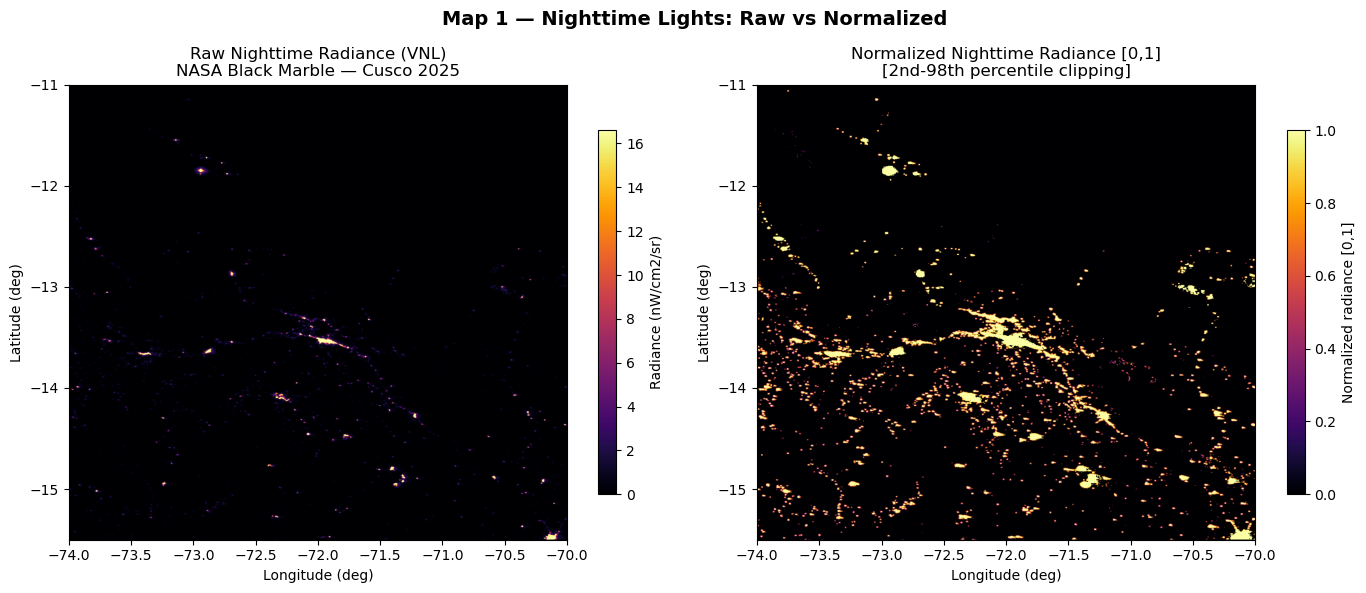

Bright zones indicate urban centers (e.g., Cusco city, Sicuani, Quillabamba)
with higher economic activity and electrification rates.
Dark zones correspond to high-altitude rural areas (Altiplano, Andes) with minimal infrastructure.


In [26]:
# Step 4 — Map 1: Raw vs Normalized Nighttime Lights (VNL)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw VNL
raw_vmax = np.percentile(vnl_data[vnl_data > 0], 98) if (vnl_data > 0).any() else 1
im0 = axes[0].imshow(
    vnl_data, cmap='inferno', extent=extent, aspect='auto', vmin=0, vmax=raw_vmax
)
axes[0].set_title('Raw Nighttime Radiance (VNL)\nNASA Black Marble — Cusco 2025', fontsize=12)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')
plt.colorbar(im0, ax=axes[0], label='Radiance (nW/cm2/sr)', shrink=0.8)

# Normalized VNL
im1 = axes[1].imshow(
    vnl_norm, cmap='inferno', extent=extent, aspect='auto', vmin=0, vmax=1
)
axes[1].set_title('Normalized Nighttime Radiance [0,1]\n[2nd-98th percentile clipping]', fontsize=12)
axes[1].set_xlabel('Longitude (deg)')
axes[1].set_ylabel('Latitude (deg)')
plt.colorbar(im1, ax=axes[1], label='Normalized radiance [0,1]', shrink=0.8)

plt.suptitle('Map 1 — Nighttime Lights: Raw vs Normalized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/map1_vnl.png', dpi=150, bbox_inches='tight')
plt.show()

print('Bright zones indicate urban centers (e.g., Cusco city, Sicuani, Quillabamba)')
print('with higher economic activity and electrification rates.')
print('Dark zones correspond to high-altitude rural areas (Altiplano, Andes) with minimal infrastructure.')

IBD range: [-1.0000, 1.0000]
EDT range: [0.0000, 1.0000]


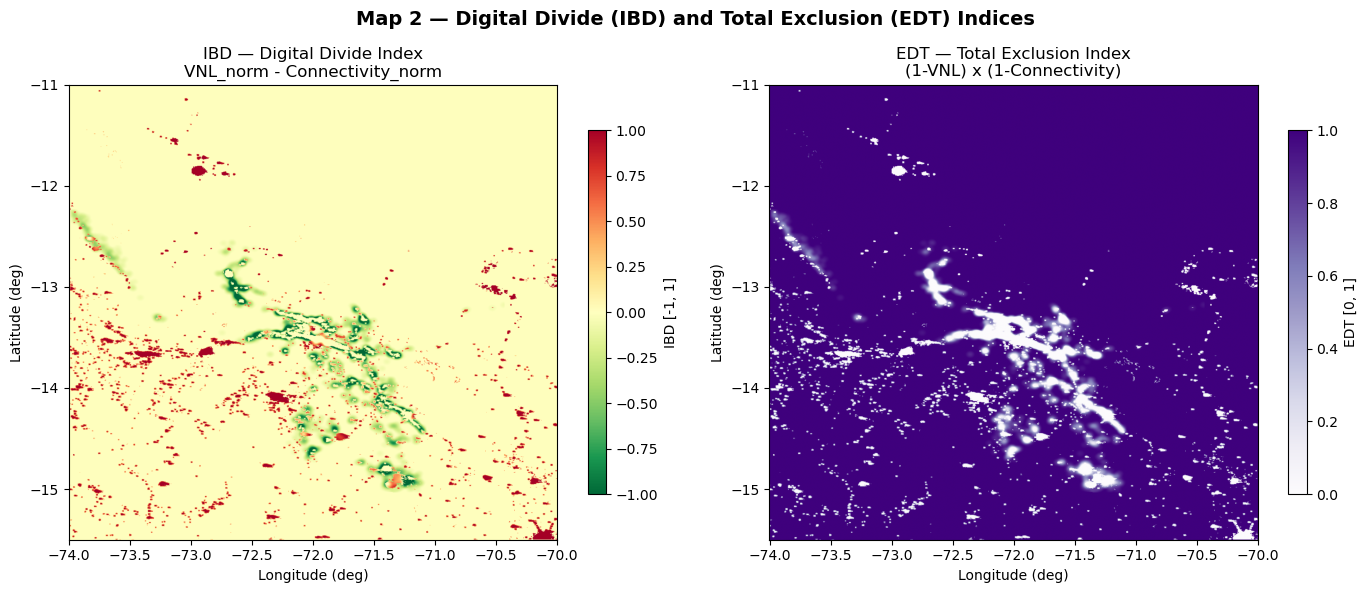

IBD Interpretation:
  Red zones (IBD > 0): areas with nighttime light but poor connectivity — active digital divide.
  Green zones (IBD < 0): areas relatively better connected than lit — lower divide risk.
  Yellow (IBD ~ 0): light and connectivity are balanced.

EDT Interpretation:
  High EDT (dark purple): zones with neither light nor connectivity — maximum total exclusion.
  Low EDT (white): urban or well-connected areas with low exclusion on both dimensions.


In [27]:
# Step 5 — Map 2: Digital Divide (IBD) and Total Exclusion (EDT) Indices
ibd = vnl_norm - conn_norm                       # Digital Divide Index [-1, 1]
edt = (1 - vnl_norm) * (1 - conn_norm)          # Total Exclusion Index [0, 1]

print(f'IBD range: [{ibd.min():.4f}, {ibd.max():.4f}]')
print(f'EDT range: [{edt.min():.4f}, {edt.max():.4f}]')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# IBD
im0 = axes[0].imshow(
    ibd, cmap='RdYlGn_r', extent=extent, aspect='auto', vmin=-1, vmax=1
)
axes[0].set_title('IBD — Digital Divide Index\nVNL_norm - Connectivity_norm', fontsize=12)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')
plt.colorbar(im0, ax=axes[0], label='IBD [-1, 1]', shrink=0.8)

# EDT
im1 = axes[1].imshow(
    edt, cmap='Purples', extent=extent, aspect='auto', vmin=0, vmax=1
)
axes[1].set_title('EDT — Total Exclusion Index\n(1-VNL) x (1-Connectivity)', fontsize=12)
axes[1].set_xlabel('Longitude (deg)')
axes[1].set_ylabel('Latitude (deg)')
plt.colorbar(im1, ax=axes[1], label='EDT [0, 1]', shrink=0.8)

plt.suptitle('Map 2 — Digital Divide (IBD) and Total Exclusion (EDT) Indices',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/map2_indices.png', dpi=150, bbox_inches='tight')
plt.show()

print('IBD Interpretation:')
print('  Red zones (IBD > 0): areas with nighttime light but poor connectivity — active digital divide.')
print('  Green zones (IBD < 0): areas relatively better connected than lit — lower divide risk.')
print('  Yellow (IBD ~ 0): light and connectivity are balanced.')
print()
print('EDT Interpretation:')
print('  High EDT (dark purple): zones with neither light nor connectivity — maximum total exclusion.')
print('  Low EDT (white): urban or well-connected areas with low exclusion on both dimensions.')

Priority Zone Summary:
  P1 Medium:     37,498 pixels (3.61%)
  P2 High:       36,148 pixels (3.48%)
  P3 Critical:   35,330 pixels (3.40%)
  No priority: 1,001,343 pixels (96.39%)


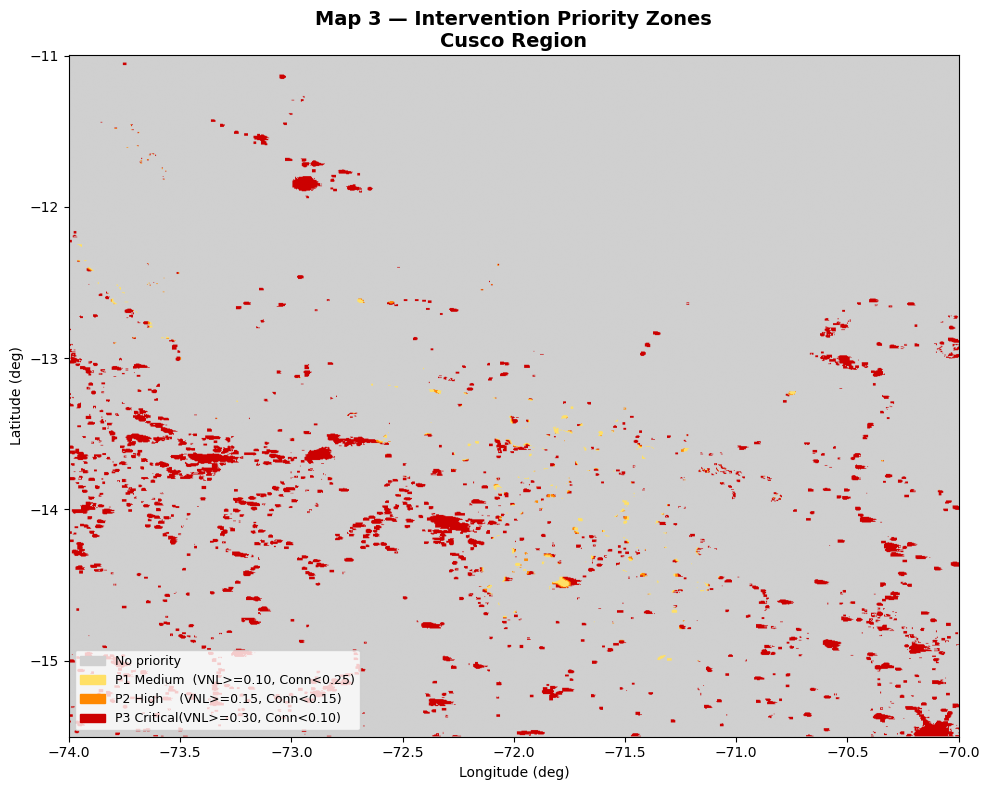

In [28]:
# Step 6 — Map 3: Intervention Priority Zones
priority = np.zeros_like(vnl_norm, dtype=np.uint8)

# Assign from lowest to highest so higher priority overwrites lower
p1_mask = (vnl_norm >= 0.10) & (conn_norm < 0.25)   # P1 Medium
p2_mask = (vnl_norm >= 0.15) & (conn_norm < 0.15)   # P2 High
p3_mask = (vnl_norm >= 0.30) & (conn_norm < 0.10)   # P3 Critical

priority[p1_mask] = 1
priority[p2_mask] = 2
priority[p3_mask] = 3

total_pixels = priority.size
print('Priority Zone Summary:')
print(f'  P1 Medium:   {p1_mask.sum():>8,} pixels ({p1_mask.sum()/total_pixels*100:.2f}%)')
print(f'  P2 High:     {p2_mask.sum():>8,} pixels ({p2_mask.sum()/total_pixels*100:.2f}%)')
print(f'  P3 Critical: {p3_mask.sum():>8,} pixels ({p3_mask.sum()/total_pixels*100:.2f}%)')
print(f'  No priority: {(priority==0).sum():>8,} pixels ({(priority==0).sum()/total_pixels*100:.2f}%)')

cmap_priority = mcolors.ListedColormap(['#d0d0d0', '#ffe066', '#ff8800', '#cc0000'])
bounds_p = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_p   = mcolors.BoundaryNorm(bounds_p, cmap_priority.N)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(priority, cmap=cmap_priority, norm=norm_p, extent=extent, aspect='auto')
ax.set_title('Map 3 — Intervention Priority Zones\nCusco Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')

legend_patches = [
    mpatches.Patch(color='#d0d0d0', label='No priority'),
    mpatches.Patch(color='#ffe066', label='P1 Medium  (VNL>=0.10, Conn<0.25)'),
    mpatches.Patch(color='#ff8800', label='P2 High    (VNL>=0.15, Conn<0.15)'),
    mpatches.Patch(color='#cc0000', label='P3 Critical(VNL>=0.30, Conn<0.10)'),
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('../output/map3_priority.png', dpi=150, bbox_inches='tight')
plt.show()

Risk score 75th percentile: 1.0000
Risk score 90th percentile: 1.0000


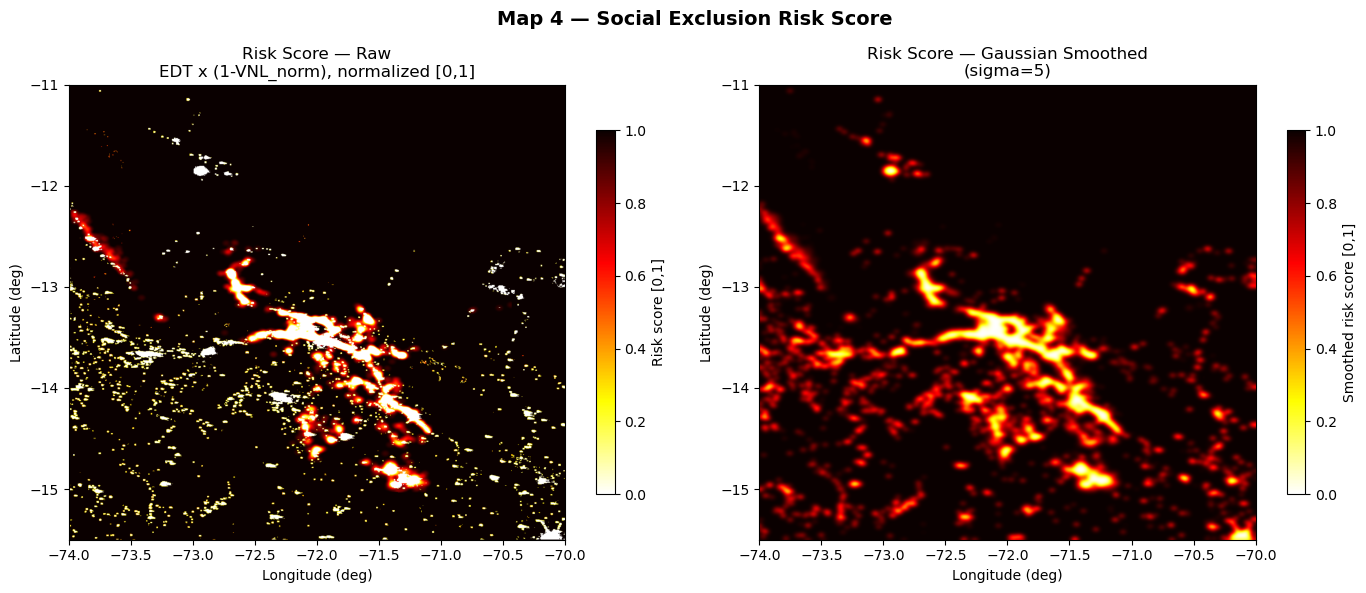

In [29]:
# Step 7 — Map 4: Social Exclusion Risk Score with Gaussian Smoothing
risk_raw  = edt * (1 - vnl_norm)
risk_min  = risk_raw.min()
risk_max  = risk_raw.max()
risk_norm = (risk_raw - risk_min) / (risk_max - risk_min + 1e-10)
risk_smooth = gaussian_filter(risk_norm, sigma=5)

p75 = np.percentile(risk_norm, 75)
p90 = np.percentile(risk_norm, 90)
print(f'Risk score 75th percentile: {p75:.4f}')
print(f'Risk score 90th percentile: {p90:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(
    risk_norm, cmap='hot_r', extent=extent, aspect='auto', vmin=0, vmax=1
)
axes[0].set_title('Risk Score — Raw\nEDT x (1-VNL_norm), normalized [0,1]', fontsize=12)
axes[0].set_xlabel('Longitude (deg)')
axes[0].set_ylabel('Latitude (deg)')
plt.colorbar(im0, ax=axes[0], label='Risk score [0,1]', shrink=0.8)

im1 = axes[1].imshow(
    risk_smooth, cmap='hot_r', extent=extent, aspect='auto', vmin=0, vmax=1
)
axes[1].set_title('Risk Score — Gaussian Smoothed\n(sigma=5)', fontsize=12)
axes[1].set_xlabel('Longitude (deg)')
axes[1].set_ylabel('Latitude (deg)')
plt.colorbar(im1, ax=axes[1], label='Smoothed risk score [0,1]', shrink=0.8)

plt.suptitle('Map 4 — Social Exclusion Risk Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/map4_risk.png', dpi=150, bbox_inches='tight')
plt.show()

 Class            Name  Pixel Count  Area %  Area km2
     1 Urban Connected        16550    1.59    3540.1
     2    Urban Divide        36148    3.48    7732.3
     3 Rural Connected        32620    3.14    6977.6
     4 Critical Divide       953523   91.79  203964.5


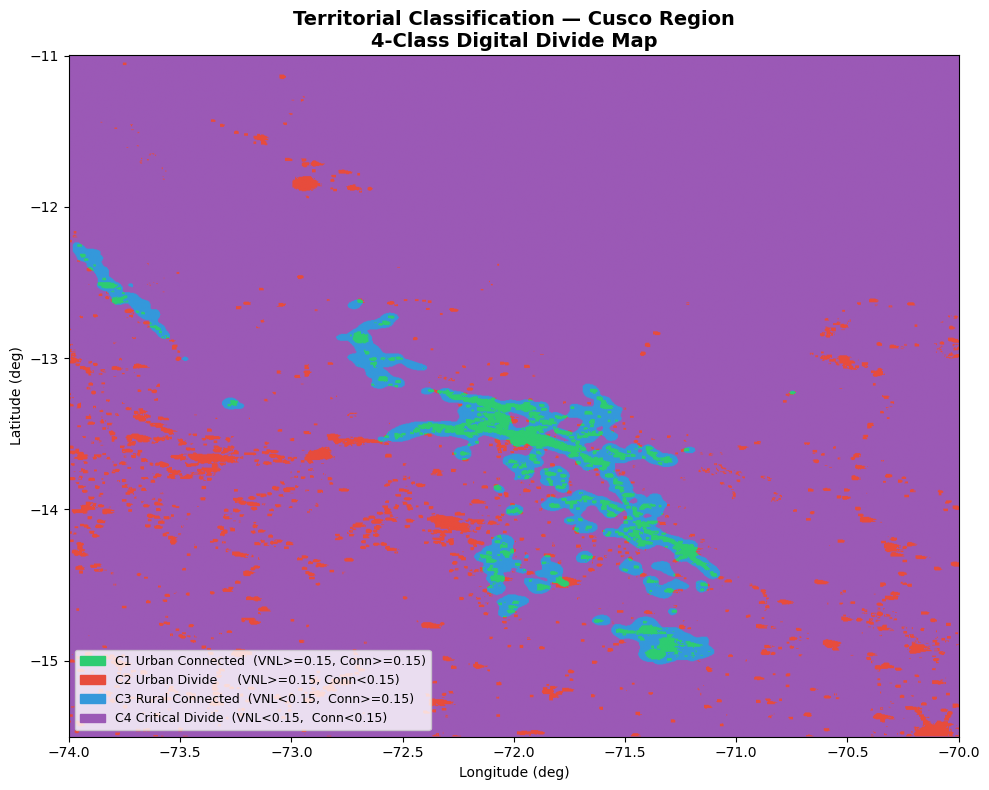


Saved: output/clasificacion_brecha.tif


In [30]:
# Step 8 — Territorial Classification (4 classes) and Export
classification = np.zeros_like(vnl_norm, dtype=np.uint8)

c1 = (vnl_norm >= 0.15) & (conn_norm >= 0.15)   # Urban Connected
c2 = (vnl_norm >= 0.15) & (conn_norm <  0.15)   # Urban Divide
c3 = (vnl_norm <  0.15) & (conn_norm >= 0.15)   # Rural Connected
c4 = (vnl_norm <  0.15) & (conn_norm <  0.15)   # Critical Divide

classification[c1] = 1
classification[c2] = 2
classification[c3] = 3
classification[c4] = 4

# Approximate area per pixel
deg_per_pixel = abs(vnl_transform.a)
km2_per_pixel = (deg_per_pixel * 111.0) ** 2

classes = [
    (1, 'Urban Connected',  '#2ecc71'),
    (2, 'Urban Divide',     '#e74c3c'),
    (3, 'Rural Connected',  '#3498db'),
    (4, 'Critical Divide',  '#9b59b6'),
]

total = classification.size
rows = []
for cid, cname, _ in classes:
    count = int((classification == cid).sum())
    rows.append({
        'Class': cid,
        'Name':  cname,
        'Pixel Count': count,
        'Area %': round(count / total * 100, 2),
        'Area km2': round(count * km2_per_pixel, 1),
    })

df_classes = pd.DataFrame(rows)
print(df_classes.to_string(index=False))

# Classification map with discrete colormap and legend
cmap_cls   = mcolors.ListedColormap(['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
bounds_cls = [0.5, 1.5, 2.5, 3.5, 4.5]
norm_cls   = mcolors.BoundaryNorm(bounds_cls, cmap_cls.N)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(classification, cmap=cmap_cls, norm=norm_cls, extent=extent, aspect='auto')
ax.set_title('Territorial Classification — Cusco Region\n4-Class Digital Divide Map', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
cls_patches = [
    mpatches.Patch(color='#2ecc71', label='C1 Urban Connected  (VNL>=0.15, Conn>=0.15)'),
    mpatches.Patch(color='#e74c3c', label='C2 Urban Divide     (VNL>=0.15, Conn<0.15)'),
    mpatches.Patch(color='#3498db', label='C3 Rural Connected  (VNL<0.15,  Conn>=0.15)'),
    mpatches.Patch(color='#9b59b6', label='C4 Critical Divide  (VNL<0.15,  Conn<0.15)'),
]
ax.legend(handles=cls_patches, loc='lower left', fontsize=9)
plt.tight_layout()
plt.show()

# Save classification raster
cls_profile = vnl_profile.copy()
cls_profile.update(dtype=rasterio.uint8, count=1, nodata=0)
with rasterio.open('../output/clasificacion_brecha.tif', 'w', **cls_profile) as dst:
    dst.write(classification, 1)
print()
print('Saved: output/clasificacion_brecha.tif')

=== Descriptive Statistics — VNL normalized ===
  Class 1 (Urban Connected): mean=0.8385  std=0.2038  min=0.3021  max=1.0000
  Class 2 (Urban Divide): mean=0.7385  std=0.2333  min=0.1579  max=1.0000
  Class 3 (Rural Connected): mean=0.0000  std=0.0000  min=0.0000  max=0.0000
  Class 4 (Critical Divide): mean=0.0000  std=0.0004  min=0.0000  max=0.1457

=== Descriptive Statistics — Connectivity normalized ===
  Class 1 (Urban Connected): mean=0.7419  std=0.2928  min=0.1500  max=1.0000
  Class 2 (Urban Divide): mean=0.0050  std=0.0211  min=0.0000  max=0.1500
  Class 3 (Rural Connected): mean=0.4585  std=0.2786  min=0.1500  max=1.0000
  Class 4 (Critical Divide): mean=0.0022  std=0.0136  min=0.0000  max=0.1500

=== Descriptive Statistics — IBD ===
  Class 1 (Urban Connected): mean=0.0966  std=0.3106  min=-0.6933  max=0.8499
  Class 2 (Urban Divide): mean=0.7335  std=0.2348  min=0.1579  max=1.0000
  Class 3 (Rural Connected): mean=-0.4585  std=0.2786  min=-1.0000  max=-0.1500
  Class 4 (Cri

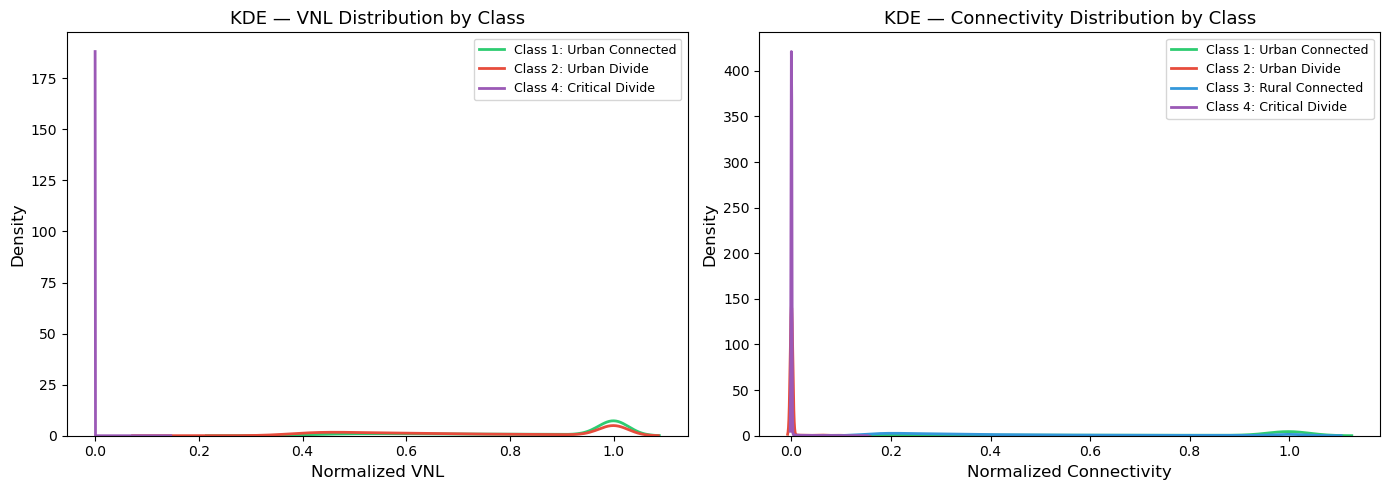

=== Welch's t-test: Class 1 (Urban Connected) vs Class 4 (Critical Divide) ===
  t-statistic: 529.3413
  p-value:     0.0000e+00
  Cohen's d:   5.8192  (large effect)


In [31]:
# Step 9 — Statistical Analysis
class_vnl  = {cid: vnl_norm[classification == cid]  for cid, _, _ in classes}
class_conn = {cid: conn_norm[classification == cid] for cid, _, _ in classes}
class_ibd  = {cid: ibd[classification == cid]       for cid, _, _ in classes}

# Descriptive statistics by class (VNL, Connectivity, IBD)
for layer_name, layer_dict in [('VNL normalized', class_vnl),
                                ('Connectivity normalized', class_conn),
                                ('IBD', class_ibd)]:
    print(f'=== Descriptive Statistics — {layer_name} ===')
    for cid, cname, _ in classes:
        v = layer_dict[cid]
        if len(v) > 0:
            print(f'  Class {cid} ({cname}): mean={v.mean():.4f}  std={v.std():.4f}  '
                  f'min={v.min():.4f}  max={v.max():.4f}')
    print()

# Pearson correlation on every 40th pixel
vnl_flat  = vnl_norm.flatten()[::40]
conn_flat = conn_norm.flatten()[::40]
r, p_corr = stats.pearsonr(vnl_flat, conn_flat)
print('=== Pearson Correlation (every 40th pixel) ===')
print(f'  r = {r:.4f}  (p-value = {p_corr:.4e})')
print()

# KDE plots — VNL and Connectivity distributions by class (one figure, two panels)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cid, cname, color in classes:
    vnl_sample  = class_vnl[cid]
    conn_sample = class_conn[cid]
    if len(vnl_sample) > 100 and vnl_sample.std() > 0:
        sns.kdeplot(vnl_sample,  ax=axes[0], label=f'Class {cid}: {cname}', color=color, linewidth=2)
    if len(conn_sample) > 100 and conn_sample.std() > 0:
        sns.kdeplot(conn_sample, ax=axes[1], label=f'Class {cid}: {cname}', color=color, linewidth=2)

axes[0].set_xlabel('Normalized VNL', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('KDE — VNL Distribution by Class', fontsize=13)
axes[0].legend(fontsize=9)

axes[1].set_xlabel('Normalized Connectivity', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('KDE — Connectivity Distribution by Class', fontsize=13)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../output/kde_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Welch's t-test: Class 1 vs Class 4
v1 = class_vnl[1]
v4 = class_vnl[4]
t_stat, p_val = stats.ttest_ind(v1, v4, equal_var=False)
cohen_d = (v1.mean() - v4.mean()) / np.sqrt((v1.std()**2 + v4.std()**2) / 2)
effect = 'large' if abs(cohen_d) >= 0.8 else 'medium' if abs(cohen_d) >= 0.5 else 'small'

print("=== Welch's t-test: Class 1 (Urban Connected) vs Class 4 (Critical Divide) ===")
print(f'  t-statistic: {t_stat:.4f}')
print(f'  p-value:     {p_val:.4e}')
print(f"  Cohen's d:   {cohen_d:.4f}  ({effect} effect)")

In [ ]:
# Step 10 — Export GeoTIFFs and Composite Dashboard
float_profile = vnl_profile.copy()
float_profile.update(dtype=rasterio.float32, count=1, nodata=0.0)

ibd_profile = vnl_profile.copy()
ibd_profile.update(dtype=rasterio.float32, count=1, nodata=-999.0)

with rasterio.open('../output/vnl_norm.tif', 'w', **float_profile) as dst:
    dst.write(vnl_norm, 1)

with rasterio.open('../output/conn_norm.tif', 'w', **float_profile) as dst:
    dst.write(conn_norm, 1)

with rasterio.open('../output/ibd_brecha_digital.tif', 'w', **ibd_profile) as dst:
    dst.write(ibd.astype(np.float32), 1)

print('GeoTIFF exports complete:')
print('  output/vnl_norm.tif')
print('  output/conn_norm.tif')
print('  output/ibd_brecha_digital.tif')
print('  output/clasificacion_brecha.tif  (saved in Step 8)')

# --- Composite dashboard ---
cmap_cls  = mcolors.ListedColormap(['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
bounds_cls = [0.5, 1.5, 2.5, 3.5, 4.5]
norm_cls   = mcolors.BoundaryNorm(bounds_cls, cmap_cls.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Digital Divide Dashboard — Cusco Region\nHW_03_202601',
             fontsize=16, fontweight='bold')

# Panel 1: Normalized VNL
ax = axes[0, 0]
im = ax.imshow(vnl_norm, cmap='inferno', extent=extent, aspect='auto', vmin=0, vmax=1)
ax.set_title('Normalized Nighttime Lights (VNL)')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
plt.colorbar(im, ax=ax, shrink=0.8, label='[0,1]')

# Panel 2: IBD
ax = axes[0, 1]
im = ax.imshow(ibd, cmap='RdYlGn_r', extent=extent, aspect='auto', vmin=-1, vmax=1)
ax.set_title('Digital Divide Index (IBD)')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
plt.colorbar(im, ax=ax, shrink=0.8, label='[-1, 1]')

# Panel 3: Priority zones
ax = axes[1, 0]
ax.imshow(priority, cmap=cmap_priority, norm=norm_p, extent=extent, aspect='auto')
ax.set_title('Intervention Priority Zones')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
dash_patches = [
    mpatches.Patch(color='#d0d0d0', label='None'),
    mpatches.Patch(color='#ffe066', label='P1 Medium'),
    mpatches.Patch(color='#ff8800', label='P2 High'),
    mpatches.Patch(color='#cc0000', label='P3 Critical'),
]
ax.legend(handles=dash_patches, loc='lower left', fontsize=7)

# Panel 4: Classification
ax = axes[1, 1]
im = ax.imshow(classification, cmap=cmap_cls, norm=norm_cls, extent=extent, aspect='auto')
ax.set_title('Territorial Classification (4 classes)')
ax.set_xlabel('Longitude (deg)')
ax.set_ylabel('Latitude (deg)')
cls_patches = [
    mpatches.Patch(color='#2ecc71', label='C1 Urban Connected'),
    mpatches.Patch(color='#e74c3c', label='C2 Urban Divide'),
    mpatches.Patch(color='#3498db', label='C3 Rural Connected'),
    mpatches.Patch(color='#9b59b6', label='C4 Critical Divide'),
]
ax.legend(handles=cls_patches, loc='lower left', fontsize=7)

plt.tight_layout()
plt.savefig('../output/dashboard_brecha_digital.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved: output/dashboard_brecha_digital.png')